# Модели семейства ARIMA для предсказания стоимости акций

ARIMA модели - семейство моделей анализа временных рядов. Модель SARIMAX даже позволяет добавить внешние признаки, например, цены других акций, или стоимость индекса мосбиржи.

SARIMAX состоит из нескольких частей:
- **S** - сезонность
- **AR** - авторегрессия (зависимость текущего значения от предыдущих значений ряда)
- **I** - интегрирование (дифференцируем ряд, чтобы сделать его стационарным)
- **MA** - скользящее среднее (зависимость текущего значения от прошлых ошибок модели)
- **X** - eXogenous variables (внешние факторы)

# Функции

In [22]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def visualize_predictions_comparison(
    results_df, title, y_label, date_column='begin', target_column='close', predict_column='predict',):
    """
    Визуализирует сравнение предсказаний и реальных изменений цены
    
    Args:
        results_df: DataFrame
        title: str, заголовок графика
        y_label: str, название оси Y
        date_column: str, название столбца с датой
        target_column: str, название столбца с target значениями
        predict_column: str, название столбца с предсказанными значениями
    """
    # Конвертируем дату если нужно
    if results_df[date_column].dtype == 'object':
        results_df = results_df.copy()
        results_df[date_column] = pd.to_datetime(results_df[date_column])
    
    # Сортируем по дате
    results_df = results_df.sort_values(date_column)
    
    fig = go.Figure()

    # Target
    fig.add_trace(
        go.Scatter(
            x=results_df[date_column],
            y=results_df[target_column],
            mode="lines+markers",
            name="target",
            line=dict(width=3, color="#2E8B57"),
            marker=dict(symbol="circle", size=6),
            opacity=0.8
        )
    )

    # Prediction
    fig.add_trace(
        go.Scatter(
            x=results_df[date_column],
            y=results_df[predict_column],
            mode="lines+markers",
            name="prediction",
            line=dict(width=3, color="#DC143C"),
            marker=dict(symbol="square", size=6),
            opacity=0.8
        )
    )

    # Нулевая линия
    fig.add_hline(
        y=0,
        line_width=1,
        line_dash="solid",
        line_color="black",
        opacity=0.5
    )

    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            xanchor="center",
            font=dict(size=18)
        ),
        xaxis_title="Дата",
        yaxis_title=y_label,
        template="plotly_white",
        width=1200,
        height=600,
        hovermode="x unified"
    )

    fig.update_xaxes(
        tickangle=45,
        showgrid=True
    )

    fig.update_yaxes(
        showgrid=True
    )

    fig.show()

def evaluate_regression(y_test, y_pred, model_name=""):
    """Оценивает результаты регрессии"""
    print(f"\n{'='*50}")
    print(f"📊 МОДЕЛЬ: {model_name}")
    print(f"{'='*50}")
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Accuracy направления (важно для торговли)
    direction_accuracy = np.mean((y_test > 0) == (y_pred > 0))
    
    print(f"MAE: {mae:.4f}%")
    print(f"RMSE: {rmse:.4f}%")
    print(f"R²: {r2:.4f}")
    print(f"Accuracy направления: {direction_accuracy:.4f}")

def add_target_after_time_delta(df, time_delta, date_column='begin', price_column='close', target_date_column='target_date', target_price_column='target'):
    """Добавляет столбец с целевой переменной - изменением цены через time_delta дней"""
    df = df.copy()
    df[target_price_column] = df[price_column].shift(-time_delta)
    df[target_date_column] = df[date_column].shift(-time_delta)
    return df

## 1. SARIMAX

### 1.1. Загружаем данные

In [3]:
# Хак, чтобы добавить корень проекта в path для импорта модулей
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[1]))
sys.path

['/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/home/codevryn/stocks-advisor/.venv/lib/python3.12/site-packages',
 '/home/codevryn/stocks-advisor']

In [4]:
from datetime import datetime

from app.core.clients.moex import Boards, Engines, Interval, Markets, MOEXClient

moex_client = MOEXClient()
stocks_data = await moex_client.get_data(
    tickers=['GAZP', 'LKOH', 'ROSN', 'SBER'],
    engine=Engines.STOCK,
    market=Markets.SHARES,
    board=Boards.TQBR,
    start_date=datetime(2022, 5, 1),
    end_date=datetime.now(),
    interval=Interval.HOUR_1,
)

In [5]:
stocks_data.keys()

dict_keys(['GAZP', 'LKOH', 'ROSN', 'SBER'])

In [6]:
stocks_data['GAZP'].describe()

,open,close,high,low,value,volume,begin,end
count,15843.000000,15843.000000,15843.000000,15843.000000,1.584300e+04,1.584300e+04,15843,15843
mean,152.039099,152.020160,152.460812,151.568551,4.856153e+08,3.223671e+06,2024-06-15 07:05:08.577920768,2024-06-15 08:04:57.197310720
min,105.620000,105.650000,105.850000,105.220000,3.017040e+04,2.600000e+02,2022-05-04 09:00:00,2022-05-04 09:59:59
25%,127.035000,127.030000,127.390000,126.700000,1.031552e+08,6.988000e+05,2023-07-04 09:30:00,2023-07-04 10:29:59
50%,153.240000,153.200000,153.700000,152.670000,2.484407e+08,1.650340e+06,2024-07-16 11:00:00,2024-07-16 11:59:59
75%,167.600000,167.620000,168.000000,167.240000,5.576363e+08,3.786655e+06,2025-06-11 10:30:00,2025-06-11 11:29:59
max,320.800000,320.800000,322.990000,319.590000,2.385369e+10,1.410863e+08,2026-03-11 20:00:00,2026-03-11 20:17:52
std,32.392664,32.373453,32.542002,32.209856,8.565981e+08,5.250878e+06,NaN,NaN


In [7]:
stocks_data['GAZP'].head()

,open,close,high,low,value,volume,begin,end,ticker
0,241.00,241.00,241.00,241.00,1.779544e+07,73840,2022-05-04 09:00:00,2022-05-04 09:59:59,GAZP
1,241.01,238.90,244.39,238.00,1.687852e+09,7012280,2022-05-04 10:00:00,2022-05-04 10:59:59,GAZP
2,238.95,233.80,240.20,233.50,1.187417e+09,5025080,2022-05-04 11:00:00,2022-05-04 11:59:59,GAZP
3,233.71,235.63,236.30,233.17,5.070772e+08,2159900,2022-05-04 12:00:00,2022-05-04 12:59:59,GAZP
4,235.63,234.61,235.84,233.90,3.604205e+08,1535620,2022-05-04 13:00:00,2022-05-04 13:59:59,GAZP


### 1.2. Обработка данных

In [8]:
stocks_data_processed = {}

for k, v_df in stocks_data.items():
    stocks_data_processed[k] = v_df[['begin', 'close']]

stocks_data_processed['GAZP'].head()

,begin,close
0,2022-05-04 09:00:00,241.00
1,2022-05-04 10:00:00,238.90
2,2022-05-04 11:00:00,233.80
3,2022-05-04 12:00:00,235.63
4,2022-05-04 13:00:00,234.61


In [ ]:
# Посмотрим на данные

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=stocks_data_processed['GAZP']["begin"],
        y=stocks_data_processed['GAZP']["close"],
        mode="lines",
        name="Close price"
    )
)

fig.update_layout(
    title="GAZP",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white"
)

fig.show()

### 1.3. Анализ данных

Пока попробуем проанализировать цены акций "в лоб" для бэйзлайна

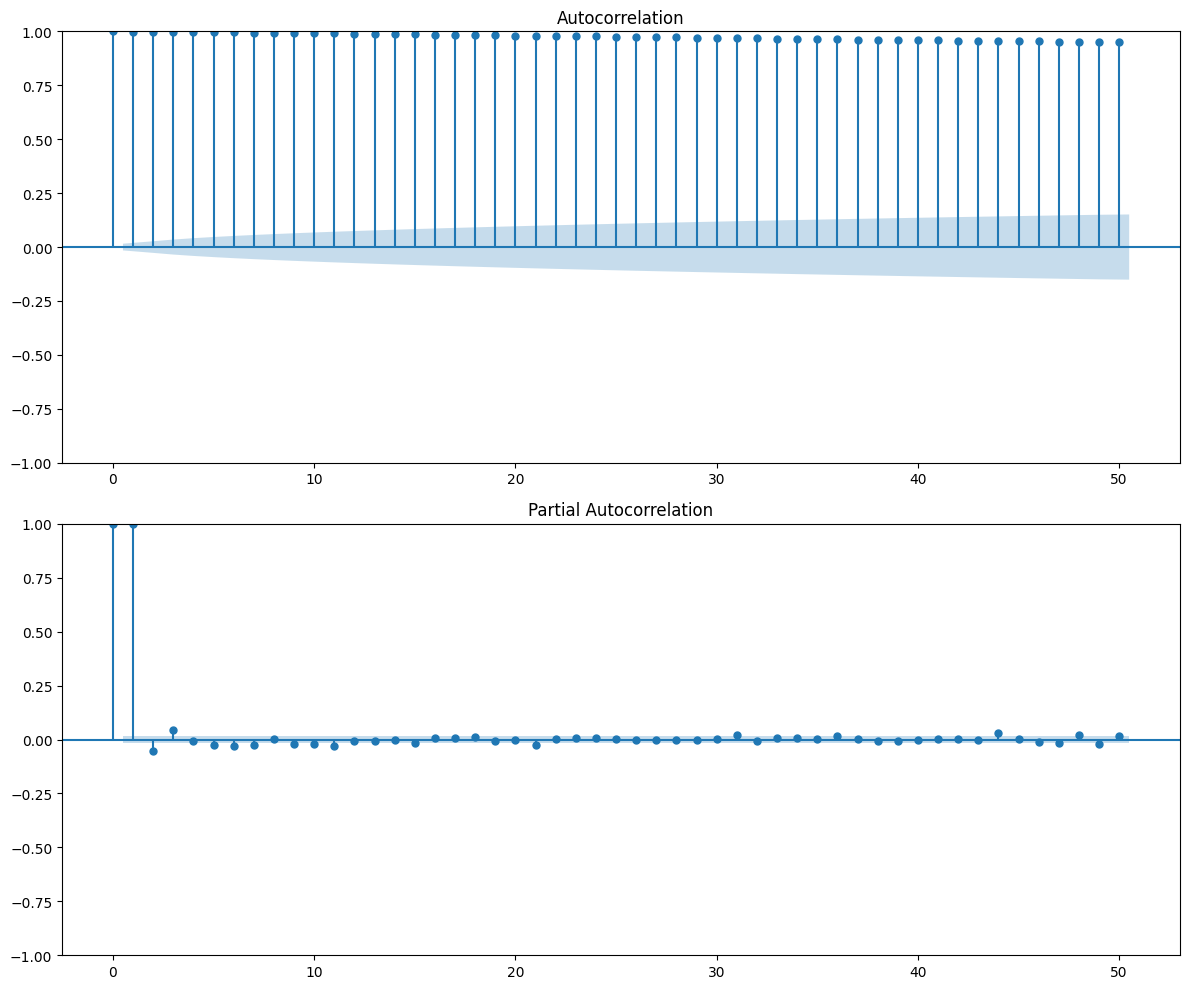

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(stocks_data_processed['GAZP']['close'], lags=50, ax=ax[0]);
plot_pacf(stocks_data_processed['GAZP']['close'], lags=50, ax=ax[1]);
plt.tight_layout()
plt.show()

Классическая картина для цен акции:
- Ряд не стационарный
- Значения в ряду сильно зависят от предыдущих значений

### 1.4. Пробуем SARIMA модель

In [23]:
# Добавим разные таргеты:
# - цена через час
# - цена через день
# - цена через неделю

stocks_data_1h = {}
stocks_data_1d = {}
stocks_data_1w = {}

for ticker, df in stocks_data_processed.items():
    stocks_data_1h[ticker] = add_target_after_time_delta(df, time_delta=1, date_column='begin', price_column='close', target_price_column='target')
    stocks_data_1d[ticker] = add_target_after_time_delta(df, time_delta=24, date_column='begin', price_column='close', target_price_column='target')
    stocks_data_1w[ticker] = add_target_after_time_delta(df, time_delta=24*7, date_column='begin', price_column='close', target_price_column='target')
stocks_data_1h['GAZP'].head()

,begin,close,target,target_date
0,2022-05-04 09:00:00,241.00,238.90,2022-05-04 10:00:00
1,2022-05-04 10:00:00,238.90,233.80,2022-05-04 11:00:00
2,2022-05-04 11:00:00,233.80,235.63,2022-05-04 12:00:00
3,2022-05-04 12:00:00,235.63,234.61,2022-05-04 13:00:00
4,2022-05-04 13:00:00,234.61,233.86,2022-05-04 14:00:00


In [ ]:
# SARIMAX модель
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(stocks_data_1h['GAZP']['close'], order=(1, 1, 0), seasonal_order=(0, 0, 0, 0))
sarimax_result = sarimax_model.fit(disp=False)
sarimax_result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  close   No. Observations:                15843
Model:               SARIMAX(1, 0, 1)   Log Likelihood              -23274.368
Date:                Wed, 11 Mar 2026   AIC                          46554.736
Time:                        20:37:17   BIC                          46577.747
Sample:                             0   HQIC                         46562.350
                              - 15843                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9999   2.34e-05   4.28e+04      0.000       1.000       1.000
ma.L1          0.0931      0.001    110.704      0.000       0.091       0.095
sigma2         1.1048      0.001   1915.285      0.000       1.104       1.106
===================================================================================
Ljung-Box (L1) (Q):                   0.25   Jarque-Bera (JB):         693384617.87
Prob(Q):                              0.61   Prob(JB):                         0.00
Heteroskedasticity (H):               0.15   Skew:                           -13.26
Prob(H) (two-sided):                  0.00   Kurtosis:                      1027.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""